In [57]:
# This code is part of QCMet.
# 
# (C) Copyright 2024 National Physical Laboratory and National Quantum Computing Centre 
# 
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
# 
#      http://www.apache.org/licenses/LICENSE-2.0
# 
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License

## Fermi-Hubbard model simulation (FHMS) metric
### Benchmarking 1D Hubbard model simulation with Trotterised time evolution

### Hubbard Hamiltonian
The 1D Hubbard model Hamiltonian is given by 
\begin{equation*}
\hat{H} = -t \sum_{i=1}^{N-1}\sum_{\sigma \in \{\uparrow,\downarrow\}} \left(\hat{c}_{i\sigma}^\dagger\hat{c}_{i+1\sigma} +\hat{c}_{i+1\sigma}^\dagger\hat{c}_{i\sigma} \right) + U \sum_{i=1}^{N} \hat{n}_{i\uparrow}\hat{n}_{i\downarrow},
\end{equation*}
where $\hat{c}^\dagger_{i\sigma}$ ($\hat{c}_{i\sigma}$) is the creation (annihilation) operator for a Fermion in site $i$ with spin $\sigma$, $\hat{n}_{i\sigma}$ is the corresponding number operator, $t$ is the hopping integral, and $U$ is the onsite energy. Typically $t$ is taken to be positive, whereas $U$ can be positive (repulsive interactions) or negative (attractive interactions).


### Fermion to Spin Mapping
In order to obtain a quantum circuit representation of the evolution operator for the Hubbard model, it is first necessary to map the fermionic system onto a system of qubits. For $N$ physical sites each with 2 spin sites, there are a total of $2N$ distinct fermionic sites. Using a Jordan-Wigner mapping, this can be mapped onto a system of $2N$ qubits. In order to do so it is first necessary to specify the ordering of the spin sites, for example
$$\{1\uparrow, 1\downarrow, 2\downarrow, 2\uparrow, \dots, N\uparrow, N\downarrow\} \rightarrow \{1, 2, 3, 4, \dots, 2N-1, 2N\}.$$

With this ordering and the use of the Jordan-Wigner mapping, the fermionic Hamiltonian $\hat{H}$ maps onto a qubit Hamiltonian of the form 
\begin{align*}
\hat{H}_q &= -t \sum_{\substack{i=1 \\ i\text{ mod } 2 = 1}}^{N-1} \left(\hat{\sigma}_{2i-1}^+ \hat{\sigma}_{2i}^z \hat{\sigma}_{2i+1}^z \hat{\sigma}_{2i+2}^- + \hat{\sigma}_{2i+2}^+ \hat{\sigma}_{2i+1}^z \hat{\sigma}_{2i}^z \hat{\sigma}_{2i-1}^-\right) 
-t \sum_{\substack{i=1 \\ i\text{ mod } 2 = 0}}^{N-1} \left(\hat{\sigma}_{2i-2}^+ \hat{\sigma}_{2i-1}^- + \hat{\sigma}_{2i-1}^+ \hat{\sigma}_{2i-2}^-\right) + \frac{U}{4} \sum_{i=1}^{N} \left(\hat{\sigma}_{2i-1}^z + \hat{1}\right)\left(\hat{\sigma}_{2i}^z + \hat{1}\right) \\
&= -t \sum_{\substack{i=1 \\ i\text{ mod } 2 = 1}}^{N-1} \left(\hat{\sigma}_{2i-1}^+ \hat{\sigma}_{2i}^z \hat{\sigma}_{2i+1}^z \hat{\sigma}_{2i+2}^- + \hat{\sigma}_{2i+2}^+ \hat{\sigma}_{2i+1}^z \hat{\sigma}_{2i}^z \hat{\sigma}_{2i-1}^-\right) 
-t \sum_{\substack{i=1 \\ i\text{ mod } 2 = 0}}^{N-1} \left(\hat{\sigma}_{2i-2}^+ \hat{\sigma}_{2i-1}^- + \hat{\sigma}_{2i-1}^+ \hat{\sigma}_{2i-2}^-\right)+ \frac{U}{4} \sum_{i=1}^{N}\hat{\sigma}_{2i-1}^z\hat{\sigma}_{2i}^z + \frac{U}{4}\sum_{i=1}^{2N} \hat{\sigma}_i^z + \frac{NU}{4}.
\end{align*}
where $\hat{\sigma}_i^z$ is the pauli-$Z$ operator acting on qubit $i$, and $\hat{\sigma}_i^\pm = \frac{1}{2}\left(\hat{\sigma}_i^{x} \pm \hat{\sigma}_i^{y}\right)$ are the qubit $i$ raising ($+$) and lowering ($-$) operators. Here, we have split the hopping terms into two sets of terms. The first corresponds to the case where we have two hopping sites with opposite spins in between (odd $i$), e.g., hopping from $1\uparrow$ to $2\uparrow$ has $1\downarrow$ and $2\downarrow$ in between, hence $\hat{\sigma}^z$ terms arise from the Jordan-Wigner mapping. The second corresponds to the case where the two hopping sites occur on neighbouring qubits (even $i$). The constant energy shift in the last term simply corresponds to an arbitrary phase rotation and so can be ignored. Consequently we can consider the qubit Hamiltonian
\begin{align*}
\hat{H}_q &= -t \sum_{\substack{i=1 \\ i\text{ mod } 2 = 1}}^{N-1} \left(\hat{\sigma}_{2i-1}^+ \hat{\sigma}_{2i}^z \hat{\sigma}_{2i+1}^z \hat{\sigma}_{2i+2}^- + \hat{\sigma}_{2i+2}^+ \hat{\sigma}_{2i+1}^z \hat{\sigma}_{2i}^z \hat{\sigma}_{2i-1}^-\right) 
-t \sum_{\substack{i=1 \\ i\text{ mod } 2 = 0}}^{N-1} \left(\hat{\sigma}_{2i-2}^+ \hat{\sigma}_{2i-1}^- + \hat{\sigma}_{2i-1}^+ \hat{\sigma}_{2i-2}^-\right)+ \frac{U}{4} \sum_{i=1}^{N}\hat{\sigma}_{2i-1}^z\hat{\sigma}_{2i}^z + \frac{U}{4}\sum_{i=1}^{2N} \hat{\sigma}_i^z
\end{align*}


### Trotterisation of the Dynamics
The dynamics associated with this model is generated by the propagator $\hat{U} = e^{-i\hat{H}t} = \left[e^{-i\hat{H}\frac{t}{N}}\right]^N,$ working in units where $\hbar=1$.  We will proceed by Trotterising the short time propagators above, noting that the Hamiltonian can be written in terms of a set of 3 commuting operators $\hat{H} = \hat{H}_o + \hat{H}_e + \hat{H}_z,$ where
\begin{align*}
\hat{H}_o &= -t \sum_{\substack{i=1 \\ i\text{ mod } 2 = 1}}^{N-1} \left(\hat{\sigma}_{2i-1}^+ \hat{\sigma}_{2i}^z \hat{\sigma}_{2i+1}^z \hat{\sigma}_{2i+2}^- + \hat{\sigma}_{2i+2}^+ \hat{\sigma}_{2i+1}^z \hat{\sigma}_{2i}^z \hat{\sigma}_{2i-1}^-\right), \\
\hat{H}_e &= -t \sum_{\substack{i=1 \\ i\text{ mod } 2 = 0}}^{N-1} \left(\hat{\sigma}_{2i-2}^+ \hat{\sigma}_{2i-1}^- + \hat{\sigma}_{2i-1}^+ \hat{\sigma}_{2i-2}^-\right), \\
\hat{H}_z &= \frac{U}{4} \sum_{i=1}^{N}\hat{\sigma}_{2i-1}^z\hat{\sigma}_{2i}^z + \frac{U}{4}\sum_{i=1}^{2N} \hat{\sigma}_i^z.
\end{align*}
The resulting Trotterised short time propagator can then be written as
\begin{equation*}
    \hat{U}_{\delta t}e^{-i\hat{H}\delta t} \approx e^{-i\hat{H}_o\delta t} e^{-i\hat{H}_e\delta t}  e^{-i\hat{H}_z\delta t} = \hat{U}_o\hat{U}_e\hat{U}_z,
\end{equation*}
where 
\begin{align*}
\hat{U}_o &=e^{-i\hat{H}_o\delta t} = \prod_{\substack{i=1 \\ i\text{ mod } 2 = 0}}^{N-1} \exp\left[i\frac{t \delta t}{2} \left(\hat{\sigma}_{2i-1}^+ \hat{\sigma}_{2i}^z \hat{\sigma}_{2i+1}^z \hat{\sigma}_{2i+2}^- + \hat{\sigma}_{2i+2}^+ \hat{\sigma}_{2i+1}^z \hat{\sigma}_{2i}^z \hat{\sigma}_{2i-1}^-\right)\right], \\ 
\hat{U}_e &=e^{-i\hat{H}_e\delta t} = \prod_{\substack{i=1 \\ i\text{ mod } 2 = 0}}^{N-1} \exp\left[i\frac{t \delta t}{2} \left(\hat{\sigma}_{2i-2}^x \hat{\sigma}_{2i-1}^x + \hat{\sigma}_{2i-2}^y \hat{\sigma}_{2i-1}^y\right)\right], \\
\hat{U}_z &=e^{-i\hat{H}_z\delta t} = \prod_{i=1}^{N} \exp\left[-i\frac{U\delta t}{4} \hat{\sigma}_{2i-1}^z\hat{\sigma}_{2i}^z\right] \exp\left[-i\frac{U\delta t}{4} \hat{\sigma}_{2i-1}^z\right] \exp\left[-i\frac{U\delta t}{4}\hat{\sigma}_{2i}^z\right].
\end{align*}

### Quantum circuit representation

The quantum circuit for each Totterised step can schematically be represented as
<center><img src="notebook_images/U.PNG" width=500/></center>

#### Interaction terms $\hat{U}_z$

We begin by considering 
\begin{equation*}
    \hat{U}_z = \prod_{i=1}^{N} \exp\left[-i\frac{U\delta t}{4} \hat{\sigma}_{2i-1}^z\hat{\sigma}_{2i}^z\right] \exp\left[-i\frac{U\delta t}{4} \hat{\sigma}_{2i-1}^z\right] \exp\left[-i\frac{U\delta t}{4}\hat{\sigma}_{2i}^z\right].
\end{equation*}
Now we note, that this consists of a product of commuting two-body $R_{zz}$ gates and $R_z$ gates, so immediately we have (example on 6 qubits)
<center><img src="notebook_images/U_z.PNG" width=600/></center>

#### Even terms $\hat{U}_e$

The propagator for the even terms
\begin{equation*}
    \hat{U}_e = \prod_{\substack{i=1 \\ i\text{ mod } 2 = 0}}^{N-1} \exp\left[i\frac{t \delta t}{2} \left(\hat{\sigma}_{2i-2}^x \hat{\sigma}_{2i-1}^x + \hat{\sigma}_{2i-2}^y \hat{\sigma}_{2i-1}^y\right)\right]
\end{equation*}
can be implemented as
<center><img src="notebook_images/U_e.PNG" width=500/></center>

where $R_{xx+yy}(\theta) = \exp\left[-i\frac{\theta}{4} \left(\hat{\sigma}_x\otimes \hat{\sigma}_x + \hat{\sigma}_y \otimes \hat{\sigma}_y \right) \right]$, and it is available in Qiskit. One way to implement this gate using $R_y$, $R_z$ and CNOT gates is as follows:
<center><img src="notebook_images/R_xx+yy.PNG" width=1400/></center>


#### Odd terms $\hat{U}_o$
The propagator for the odd terms 
\begin{equation*}
    \hat{U}_o = \prod_{\substack{i=1 \\ i\text{ mod } 2 = 0}}^{N-1} \exp\left[i\frac{t \delta t}{2} \left(\hat{\sigma}_{2i-1}^+ \hat{\sigma}_{2i}^z \hat{\sigma}_{2i+1}^z \hat{\sigma}_{2i+2}^- + \hat{\sigma}_{2i+2}^+ \hat{\sigma}_{2i+1}^z \hat{\sigma}_{2i}^z \hat{\sigma}_{2i-1}^-\right)\right], 
\end{equation*}
appears as if it is significantly more involved to evaluate. However, we note that by simply swapping the spin on each site, the ordering becomes
\begin{equation*}
    \{1\downarrow, 1\uparrow, 2\uparrow, 2\downarrow, \dots, N\downarrow, N\uparrow\},
\end{equation*} 
and consequently, each of the hopping terms that was previously introducing four-body operators, now can be implemented using two-body terms.  Following this swap it is then necessary to return the system to the original ordering. As such, we can implement the odd unitary terms as 
<center><img src="notebook_images/U_o.PNG" width=800/></center>

where $F_{swap} = \begin{pmatrix} 
    1 & 0 & 0 & 0\\
    0 & 0 & 1 & 0\\
    0 & 1 & 0 & 0\\
    0 & 0 & 0 & -1
    \end{pmatrix}$ and can be implemented using CNOT and Hadamard gates as
<center><img src="notebook_images/F_swap.PNG" width=800/></center>

#### Full circuit
Combining the above, we obtain the full circuit for each Trotterised step as
<center><img src="notebook_images/U_full.PNG" width=1400/></center>

Below is the code to create the circuit according to specific Hubbard model parameters. Simulations of the circuit will then be carried out and a normalised fidelity of the obtained final probability distribution of possible bitstrings against the ideal will be computed.

### Imports

In [1]:
import qiskit
from qiskit.quantum_info import Operator
from qiskit.circuit.library import XXPlusYYGate
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
import pathlib
import os
sys.path.insert(0, str(pathlib.Path(os.path.abspath('')).parent.parent.parent.resolve()))

from _helpers.circuit_submitter import *

### Definitions of $R_{xx+yy}$ gate and $F_{swap}$ gate 

In [3]:
def add_xx_plus_yy(circuit: qiskit.QuantumCircuit, i: int, theta: float, 
                   verbose: bool = False):
    """
    Add an XX+YY gate to the circuit

    Params:
        circuit: qiskit.QuantumCircuit to add the gate to
        i: index of the first qubit to act on
        theta: rotation angle
        verbose: whether to decompose XX+YY into CX, Ry and Rz or not
    """
    j = i + 1
    if verbose:
        circuit.cx(j, i)
        circuit.ry(np.pi / 4, j)
        circuit.cx(i, j)
        circuit.ry(-np.pi / 4, j)
        circuit.cx(j, i)
        circuit.rz(2 * theta, i)
        circuit.rz(-2 * theta, j)
        circuit.cx(j, i)
        circuit.ry(-np.pi / 4, j)
        circuit.cx(i, j)
        circuit.ry(np.pi / 4, j)
        circuit.cx(j, i)
    else:
        circuit.append(XXPlusYYGate(theta), [i, j])


def add_fswap(circuit: qiskit.QuantumCircuit, i: int, verbose: bool = False):
    """
    Add an F_swap gate to the circuit

    Params:
        circuit: qiskit.QuantumCircuit to add the gate to
        i: index of the first qubit to act on
        verbose: whether to decompose F_swap into CX and H or not
    """
    j = i + 1
    if verbose:
        circuit.cx(i, j)
        circuit.cx(j, i)
        circuit.cx(i, j)
        circuit.h(j)
        circuit.cx(i, j)
        circuit.h(j)
    else:
        op = Operator([[1, 0, 0, 0],
                       [0, 0, 1, 0],
                       [0, 1, 0, 0],
                       [0, 0, 0, -1]])
        circuit.unitary(op, [i, j], label="F_swap")


### Function to create the circuit according to specific parameters

In [4]:
def hubbard_model_circuit(N: int, t: float, U: float, dt: float, steps: int, 
                          initial_state: list[int], verbose: bool = False):
    """
    Constructs a quantum circuit for Totterising a 1d Hubbard model Hamiltonian evolution

    Params:
        N: the number of Fermionic sites
        t: the hopping integral
        U: the onsite energy
        dt: time for each Totterisation step
        steps: the number of Totterisation steps
        initial_state: list of qubits to initialise into |1> instead of |0>
        verbose: whether to decompose all gates into elementary gates
    
    Returns:
        A qiskit QuantumCircuit representing the Totterised evolution
    """

    no_qubits = 2 * N
    circuit = qiskit.QuantumCircuit(no_qubits)
    theta = -2 * t * dt

    for i in initial_state:
        if i < no_qubits:
            circuit.x(i)

    for _ in range(steps):
        # U_z
        for qubit in range(no_qubits):
            circuit.rz(U * dt / 2, qubit)
        for qubit in range(0, no_qubits, 2):
            circuit.rzz(U * dt / 2, qubit, qubit + 1)

        # U_e and U_o
        for _ in range(2):
            for qubit in range(1, no_qubits - 1, 2):
                add_xx_plus_yy(circuit, qubit, theta, verbose)
            for qubit in range(0, no_qubits, 2):
                add_fswap(circuit, qubit, verbose)

    return circuit

### Set Hubbard model parameters and create the circuit

In [5]:
N = 2
t = 2
U = 2
dt = 0.5
steps = 3
initial_state = [0]
device_name = "noisy_sim"

circuit = hubbard_model_circuit(N=N, t=t, U=U, dt=dt, steps=steps, initial_state=initial_state, verbose=False)

In [6]:
submitter = CircuitSubmitter("hubbard_model_simulation", device_name)
# Uncomment the following lines if you are using a noisy simulator and would like to change the noise model
# noise_model = None
# submitter.backend.device.noisy_sim.set_options(noise_model=noise_model)

NoiseModel:
  Basis gates: ['cx', 'id', 'rz', 'sx']
  Instructions with noise: ['sx', 'measure', 'reset', 'id', 'cx']
  Qubits with noise: [0, 1, 2, 3]
  Specific qubit errors: [('reset', (0,)), ('reset', (1,)), ('reset', (2,)), ('reset', (3,)), ('measure', (0,)), ('measure', (1,)), ('measure', (2,)), ('measure', (3,)), ('sx', (0,)), ('sx', (1,)), ('sx', (2,)), ('sx', (3,)), ('id', (0,)), ('id', (1,)), ('id', (2,)), ('id', (3,)), ('cx', (0, 0)), ('cx', (0, 1)), ('cx', (0, 2)), ('cx', (0, 3)), ('cx', (1, 0)), ('cx', (1, 1)), ('cx', (1, 2)), ('cx', (1, 3)), ('cx', (2, 0)), ('cx', (2, 1)), ('cx', (2, 2)), ('cx', (2, 3)), ('cx', (3, 0)), ('cx', (3, 1)), ('cx', (3, 2)), ('cx', (3, 3))]


### Exact state vector simulations to obtain ideal results

/home/dsl/.conda/envs/cqc/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


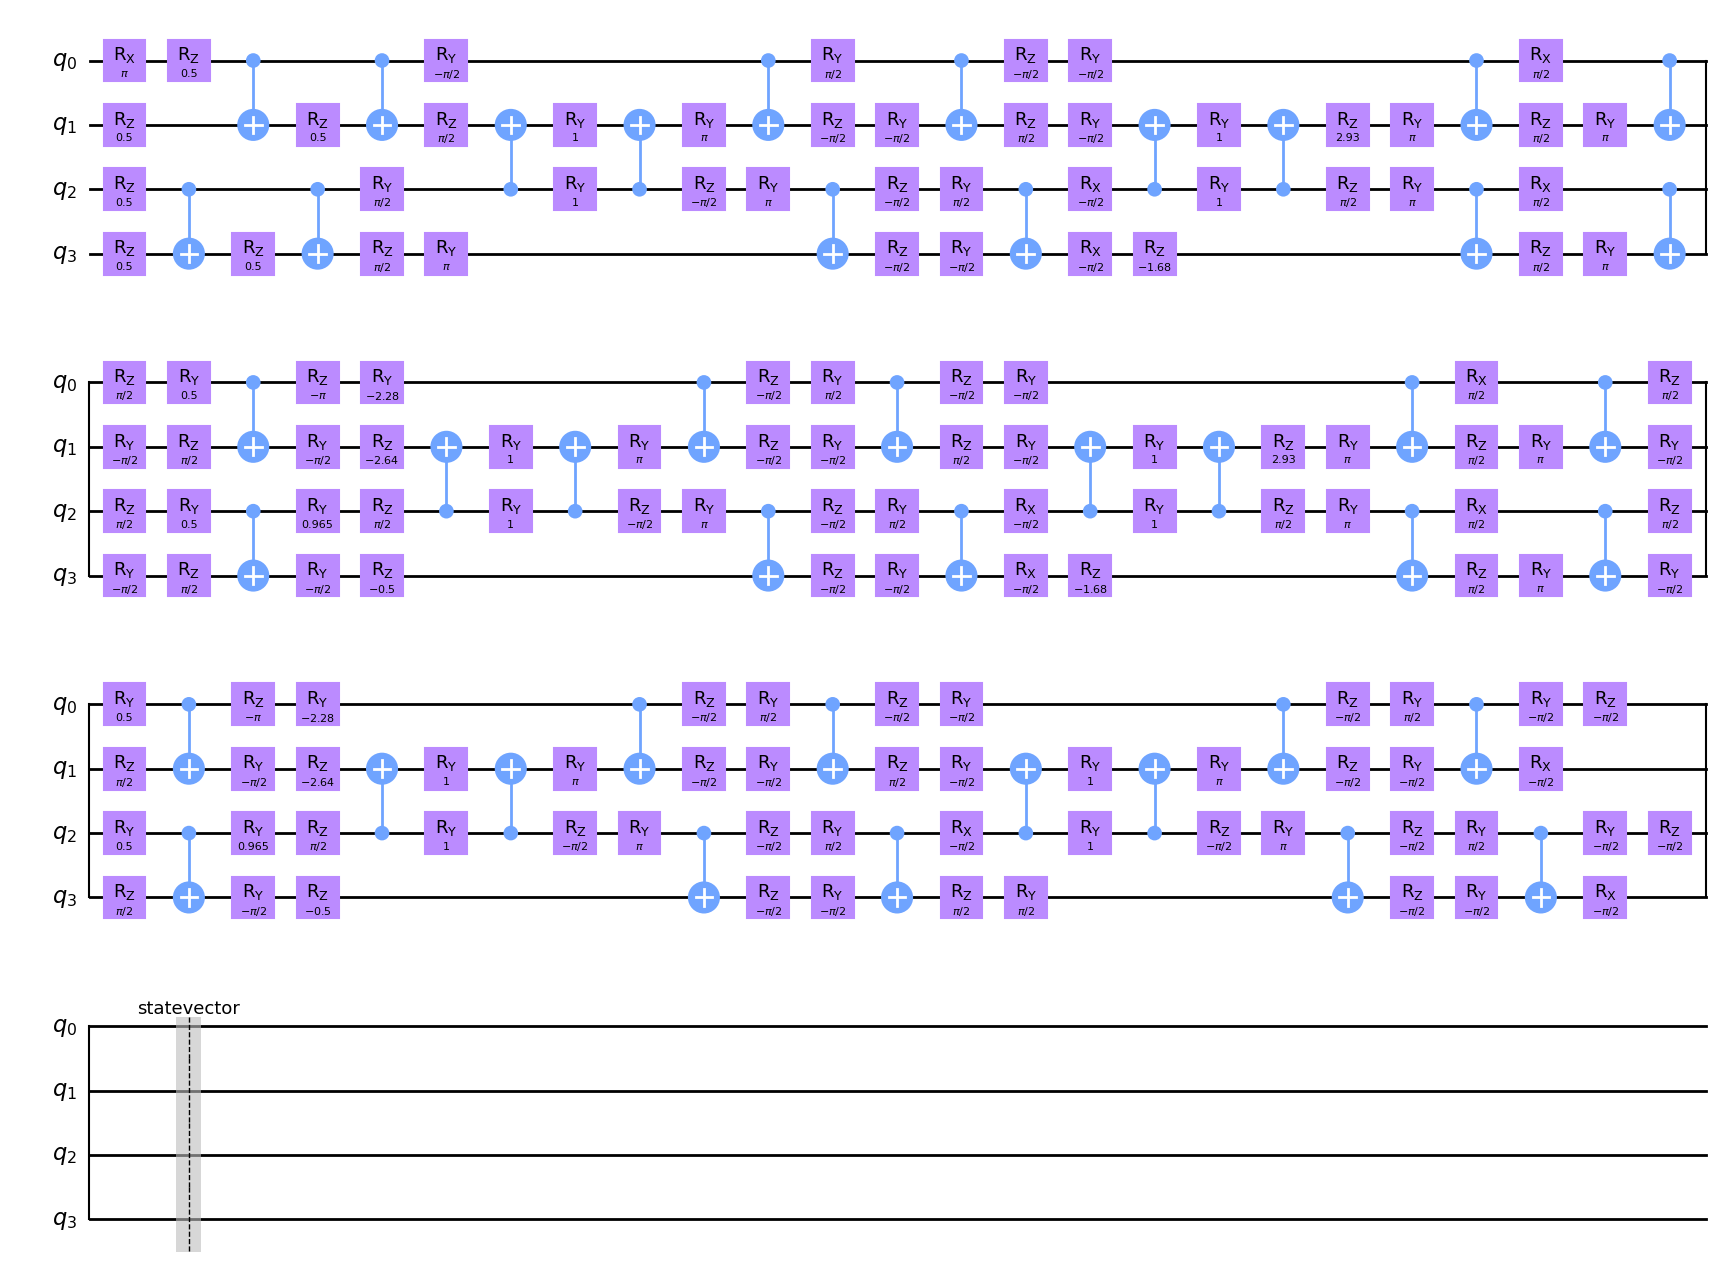

In [7]:
transpiled_circuit = qiskit.transpile(circuit, basis_gates=["rx", "ry", "rz", "cx"], optimization_level=3)
exact_circ = transpiled_circuit.copy()
exact_circ.save_statevector()
exact_circ.draw("mpl")

In [8]:
sim = AerSimulator()
sv = np.asarray(sim.run(exact_circ).result().get_statevector())
exact_probs = [np.linalg.norm(e) ** 2 for e in sv]
print(exact_probs)

[2.836608927856279e-32, 0.9800851433251814, 3.8248188167281536e-32, 1.4885331984236664e-31, 2.0848191647991823e-32, 2.0954117794933126e-31, 1.3359681376191426e-32, 5.116052341332405e-32, 0.01991485667481701, 2.7290427311967128e-31, 8.428205157825137e-32, 1.1630811304776032e-32, 1.295187887600417e-32, 6.317050217590135e-32, 3.400437144216889e-32, 1.7769713002510397e-32]


In [9]:
def fidelity(P1, P2):
    assert len(P1) == len(P2)
    
    f = 0
    for i in range(len(P1)):
        f += np.sqrt(P1[i] * P2[i])
    
    f = f ** 2
    
    return f

uniform_dist = np.array([1 for _ in exact_probs]) / len(exact_probs)


# Run on AWS or noisy simulator

In [10]:
shots = 1000
tasks = submitter.submit_circuits(shots=shots, skip_asking=False, qasm_strs=[transpiled_circuit.qasm()])

Ready to run 1 circuits on noisy_sim with 1000 shots.
Cost: 1 * ($0 + 1000 * $0) = $0.00.


Submitting circuits...
Circuits have been submitted


In [11]:
hardware_counts = submitter.convert_counts_to_qiskit(
    submitter.retrieve_counts([task.id for task in tasks], wait=True)[0])
# Convert base 2 into base 10
hardware_counts = {int(key, 2): value for key, value in hardware_counts.items()}
# Sort according to ascending order of bit strings
hardware_list = np.array([hardware_counts[i] if i in hardware_counts.keys() else 0 for i in range(2 ** (2 * N))])
# Convert to probabilities
hardware_probs = hardware_list / shots

2024-07-05 17:42:04 All circuits are finished


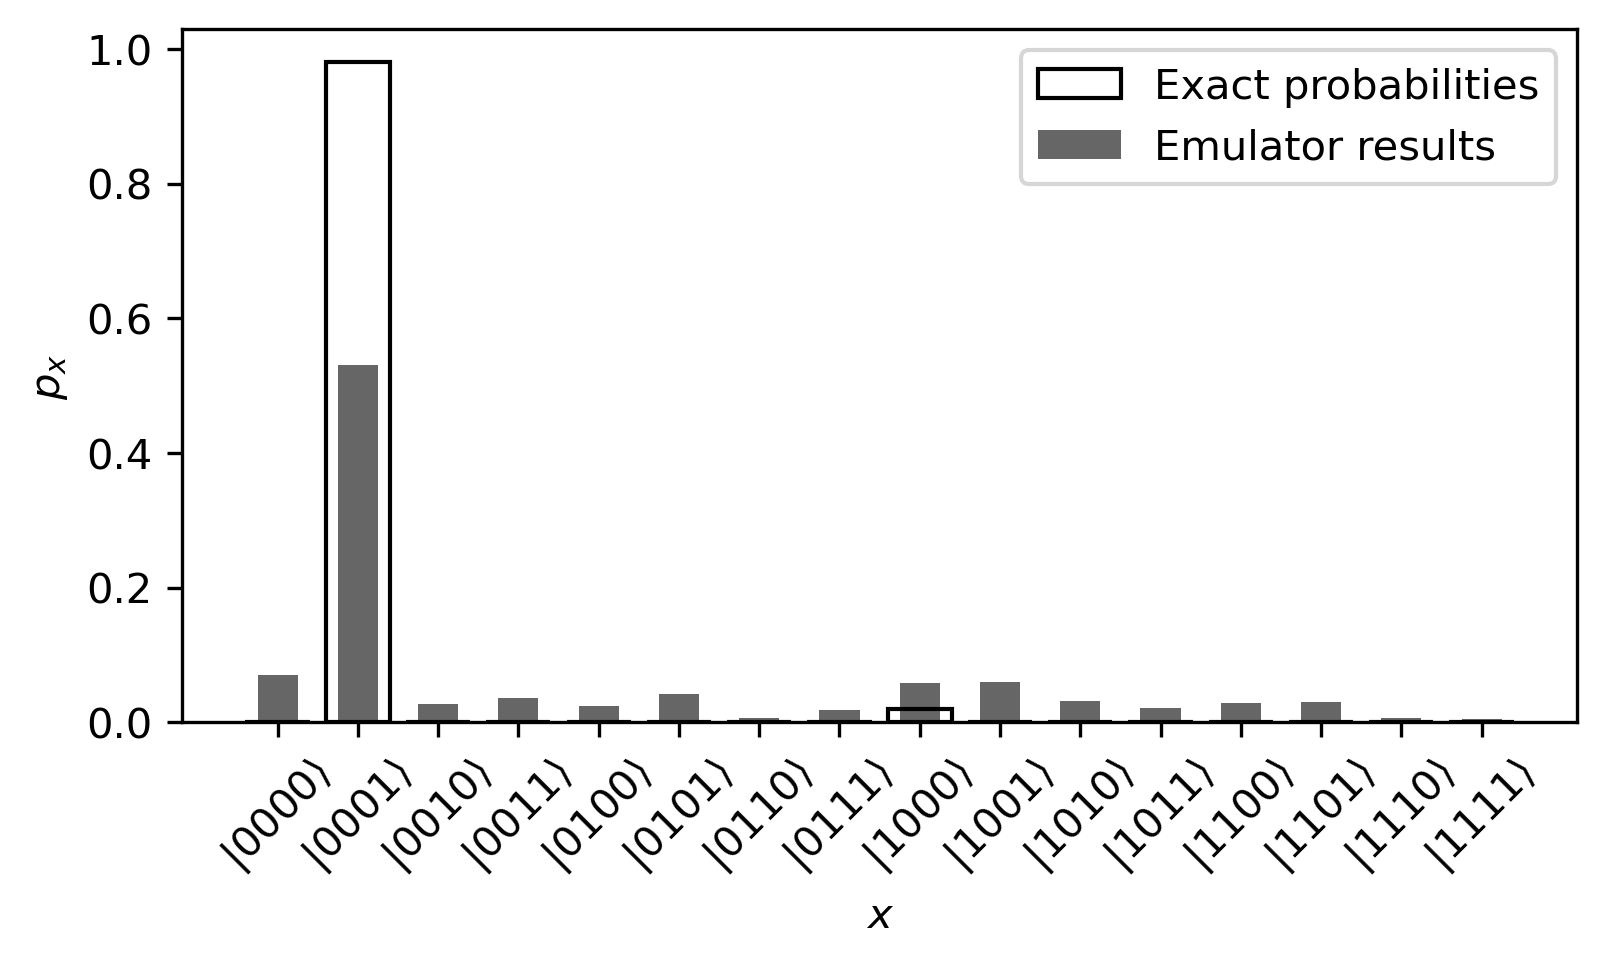

In [12]:
from matplotlib.ticker import StrMethodFormatter

xlabels = [rf'$\vert{i:04b}\rangle$' for i in range(16)]
# print(xlabels)

fig = plt.figure(figsize = (6,3), dpi=300)
plt.bar(np.arange(0,16, dtype=int),exact_probs, label="Exact probabilities", edgecolor='black', color='none')
plt.bar(np.arange(0,16, dtype=int),hardware_probs,width=0.5, label="Emulator results", color='black', alpha=0.6)
plt.xticks(range(0,16), xlabels, rotation=45, fontsize=10)
plt.xlabel(r"$x$")
plt.ylabel(r"$p_x$")
plt.legend()
plt.show()

### Compute normalised fidelity

In [27]:
uniform_dist = np.array([1 for _ in exact_probs]) / len(exact_probs)

f_ideal_and_output = fidelity(exact_probs, hardware_probs)
f_ideal_and_uniform = fidelity(exact_probs, uniform_dist)

f_ideal_and_hardware = fidelity(exact_probs, hardware_probs)

normalised_fidelity = max((f_ideal_and_hardware - f_ideal_and_uniform) / (1 - f_ideal_and_uniform), 0)
print(f"The normalised fidelity between the exact result and the hardware result is {normalised_fidelity}")

# Save into data directory
result_str = (f"1D Hubbard model Trotter evolution simulation with parameters N={N}, t={t}, U={U}, dt={dt}\n"
                f"Exact (ideal) probabilities: {exact_probs}\n" 
                f"Obtained (hardware) probabilities: {hardware_probs}\n" 
                f"The normalised fidelity between the exact result and the hardware result is {normalised_fidelity}")
with open(submitter.benchmark_path + "/results.txt", "w+") as f:
    f.write(result_str)
print(result_str)
print(f"The above results are saved into {'/'.join(submitter.benchmark_path.split('/')[-4:]) + '/results.txt'}")

The normalised fidelity between the exact result and the hardware result is 0.5332966857358765
1D Hubbard model Trotter evolution simulation with parameters N=2, t=2, U=2, dt=0.5
Exact (ideal) probabilities: [2.836608927856279e-32, 0.9800851433251814, 3.8248188167281536e-32, 1.4885331984236664e-31, 2.0848191647991823e-32, 2.0954117794933126e-31, 1.3359681376191426e-32, 5.116052341332405e-32, 0.01991485667481701, 2.7290427311967128e-31, 8.428205157825137e-32, 1.1630811304776032e-32, 1.295187887600417e-32, 6.317050217590135e-32, 3.400437144216889e-32, 1.7769713002510397e-32]
Obtained (hardware) probabilities: [0.071 0.531 0.027 0.037 0.025 0.042 0.007 0.018 0.058 0.06  0.032 0.022
 0.029 0.03  0.006 0.005]
The normalised fidelity between the exact result and the hardware result is 0.5332966857358765
The above results are saved into hardware_runs/noisy_sim/2024-07-05/hubbard_model_simulation/results.txt
